In [2]:
# STEP 1 — SETUP
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, precision_recall_curve, f1_score
import seaborn as sns

from rfdetr import RFDETRSmall

# === CONFIG ===
MODEL_PATH = "./output/checkpoint_best_ema.pth"
VAL_IMAGES_DIR = "./dataset/brain_tumor/valid"
VAL_ANNOTATIONS = "./dataset/brain_tumor/valid/_annotations.coco.json"
OUTPUT_DIR = "./rfdetr_val_results"
CONF_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define your class names (same order as training)
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

print(f"✅ Setup complete. Output folder: {OUTPUT_DIR}")


✅ Setup complete. Output folder: ./rfdetr_val_results


In [3]:
# STEP 2 — LOAD MODEL & DATASET
model = RFDETRSmall(pretrain_weights=MODEL_PATH)

# Load COCO-style annotations
with open(VAL_ANNOTATIONS, "r") as f:
    val_data = json.load(f)

images_info = {im["id"]: im for im in val_data["images"]}
annotations_by_img = {im["id"]: [] for im in val_data["images"]}
for ann in val_data["annotations"]:
    annotations_by_img[ann["image_id"]].append(ann)

print(f"✅ Loaded {len(images_info)} validation images and annotations.")


Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
✅ Loaded 1074 validation images and annotations.


In [12]:
# === Correct class configuration for Brain Tumor COCO dataset ===
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

# Map COCO category IDs to class indices (skip the meta-class id=0)
category_id_to_index = {
    1: 0,  # Glioma
    2: 1,  # Meningioma
    3: 2,  # No Tumor
    4: 3   # Pituitary
}

print("✅ Using mapping:", category_id_to_index)


✅ Using mapping: {1: 0, 2: 1, 3: 2, 4: 3}


In [13]:
import collections
counter = collections.Counter([a["category_id"] for a in val_data["annotations"]])
print(counter)


Counter({1: 404, 4: 361, 2: 316, 3: 143})


In [36]:
# STEP 3 — SAVE INDIVIDUAL PRED AND LABEL IMAGES
import os, json
from PIL import Image, ImageDraw, ImageFont
import supervision as sv
from rfdetr import RFDETRSmall

# === CONFIG ===
VAL_DIR = "./dataset/brain_tumor/valid"
VAL_ANN_PATH = os.path.join(VAL_DIR, "_annotations.coco.json")
MODEL_PATH = "./output/checkpoint_best_ema.pth"
OUTPUT_DIR = "./rfdetr_val_results_single"
CONF_THRESHOLD = 0.5

os.makedirs(OUTPUT_DIR, exist_ok=True)

# === CLASSES / MAPPING ===
class_names = ['Mixed', 'Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
category_id_to_index = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}

# === LOAD MODEL & ANNOTATORS ===
model = RFDETRSmall(pretrain_weights=MODEL_PATH)
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()
print("✅ Model loaded from:", MODEL_PATH)

# === LOAD COCO ANNOTATIONS ===
with open(VAL_ANN_PATH, "r") as f:
    val_data = json.load(f)

images_info = {img["id"]: img for img in val_data["images"]}
annotations_by_img = {img["id"]: [] for img in val_data["images"]}
for ann in val_data["annotations"]:
    annotations_by_img[ann["image_id"]].append(ann)

print(f"✅ Loaded {len(images_info)} validation images from COCO file")

# === LOOP OVER IMAGES ===
for img_id, info in images_info.items():
    file_name = info["file_name"]
    img_path = os.path.join(VAL_DIR, file_name)
    if not os.path.exists(img_path):
        continue

    image = Image.open(img_path).convert("RGB")

    # --- Ground-truth LABEL image (Enhanced Readability, Pillow 10+ compatible) ---
    img_labels = image.copy()
    draw = ImageDraw.Draw(img_labels)
    
    # Larger font size for readability
    try:
        font = ImageFont.truetype("arial.ttf", 16)
    except:
        font = ImageFont.load_default()
    
    gt_anns = annotations_by_img.get(img_id, [])
    for ann in gt_anns:
        bbox = ann["bbox"]  # [x, y, w, h]
        cls = category_id_to_index.get(ann["category_id"], None)
        if cls is None:
            continue
    
        x, y, w, h = bbox
        label_text = class_names[cls]
    
        # Draw bounding box (lime/green)
        draw.rectangle([x, y, x + w, y + h], outline="lime", width=2)
    
        # --- Compute text size using Pillow-safe method ---
        margin = 4
        try:
            # New Pillow versions (>=10)
            left, top, right, bottom = draw.textbbox((x, y), label_text, font=font)
            text_w, text_h = right - left, bottom - top
        except AttributeError:
            # Fallback for older Pillow
            text_w, text_h = font.getsize(label_text)
    
        # Background rectangle (green with alpha-like fill)
        text_bg_x1 = x
        text_bg_y1 = max(0, y - text_h - 2 * margin)
        text_bg_x2 = x + text_w + 2 * margin
        text_bg_y2 = y
    
        draw.rectangle(
            [text_bg_x1, text_bg_y1, text_bg_x2, text_bg_y2],
            fill=(0, 255, 0)
        )
    
        # Draw text label
        draw.text(
            (x + margin, text_bg_y1 + margin),
            label_text,
            fill="black",
            font=font
        )

    # --- Prediction image (using Supervision) ---
    detections = model.predict(image, threshold=CONF_THRESHOLD)
    pred_labels = [
        f"{class_names[int(cid)]} {conf:.2f}"
        for cid, conf in zip(detections.class_id.tolist(), detections.confidence.tolist())
    ]
    img_pred = image.copy()
    img_pred = box_annotator.annotate(img_pred, detections)
    img_pred = label_annotator.annotate(img_pred, detections, labels=pred_labels)

    # --- SAVE ---
    label_out = os.path.join(OUTPUT_DIR, f"{os.path.splitext(file_name)[0]}_labels.jpg")
    pred_out  = os.path.join(OUTPUT_DIR, f"{os.path.splitext(file_name)[0]}_pred.jpg")
    img_labels.save(label_out)
    img_pred.save(pred_out)

    print(f"🖼️ Saved: {os.path.basename(label_out)}  |  {os.path.basename(pred_out)}")
    # break

print(f"✅ Done! All labeled & predicted images saved under: {os.path.abspath(OUTPUT_DIR)}")


Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


✅ Model loaded from: ./output/checkpoint_best_ema.pth
✅ Loaded 1074 validation images from COCO file
🖼️ Saved: p-821-_jpg.rf.e882dd04646a87ba37b2a769fd775f17_labels.jpg  |  p-821-_jpg.rf.e882dd04646a87ba37b2a769fd775f17_pred.jpg
🖼️ Saved: p-85-_jpg.rf.9dd4d583715d541ba7ff80ef8df2d0cd_labels.jpg  |  p-85-_jpg.rf.9dd4d583715d541ba7ff80ef8df2d0cd_pred.jpg
🖼️ Saved: p-83-_jpg.rf.b767b8fbe6bf75729c0be1cb7fef3518_labels.jpg  |  p-83-_jpg.rf.b767b8fbe6bf75729c0be1cb7fef3518_pred.jpg
🖼️ Saved: p-827-_jpg.rf.51ad2175e840f31ba69f0668ab38f318_labels.jpg  |  p-827-_jpg.rf.51ad2175e840f31ba69f0668ab38f318_pred.jpg
🖼️ Saved: p-9-_jpg.rf.1443ad8233fcf7215fdff277329dc499_labels.jpg  |  p-9-_jpg.rf.1443ad8233fcf7215fdff277329dc499_pred.jpg
🖼️ Saved: p-87-_jpg.rf.61bad69d1213094e3bc9176a13409c92_labels.jpg  |  p-87-_jpg.rf.61bad69d1213094e3bc9176a13409c92_pred.jpg
🖼️ Saved: Tr-gl_0245_jpg.rf.b8885f648f0b72df803ec6b5c8347980_labels.jpg  |  Tr-gl_0245_jpg.rf.b8885f648f0b72df803ec6b5c8347980_pred.jpg
🖼️ Sa

In [ ]:
# STEP 4 — COCO-Style Evaluation (mAP, PR/F1 curves, confusion matrix)
import os, json, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from PIL import Image
from rfdetr import RFDETRSmall
import supervision as sv

# === CONFIG ===
VAL_DIR = "./dataset/brain_tumor/valid"
VAL_ANN_PATH = os.path.join(VAL_DIR, "_annotations.coco.json")
MODEL_PATH = "./output/checkpoint_best_ema.pth"
OUTPUT_DIR = "./rfdetr_eval_results"
CONF_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5

os.makedirs(OUTPUT_DIR, exist_ok=True)

# === CLASS NAMES ===
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

# === LOAD MODEL ===
model = RFDETRSmall(pretrain_weights=MODEL_PATH)
print("✅ Model loaded from:", MODEL_PATH)

# === LOAD COCO GT ===
coco_gt = COCO(VAL_ANN_PATH)

# === RUN PREDICTIONS & BUILD COCO-FORMAT DETECTIONS JSON ===
results = []
image_files = {img["file_name"]: img["id"] for img in coco_gt.dataset["images"]}

for file_name, img_id in tqdm(image_files.items(), desc="Evaluating"):
    img_path = os.path.join(VAL_DIR, file_name)
    image = Image.open(img_path).convert("RGB")

    detections = model.predict(image, threshold=CONF_THRESHOLD)
    boxes = detections.xyxy
    scores = detections.confidence
    labels = detections.class_id

    # use same mapping as Step 3
    category_id_to_index = {1: 0, 2: 1, 3: 2, 4: 3}
    index_to_category_id = {v: k for k, v in category_id_to_index.items()}  # reverse map
    
    for box, score, label in zip(boxes, scores, labels):
        # skip meta-class 0
        if int(label) == 0:
            continue
    
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        coco_category_id = index_to_category_id.get(int(label), int(label))
    
        results.append({
            "image_id": int(img_id),
            "category_id": coco_category_id,  # ✅ correct COCO IDs (1–4)
            "bbox": [float(x1), float(y1), float(w), float(h)],
            "score": float(score)
        })


# Save predictions JSON
pred_json_path = os.path.join(OUTPUT_DIR, "detections_coco_format.json")
with open(pred_json_path, "w") as f:
    json.dump(results, f)
print(f"💾 Saved predictions: {pred_json_path}")

# === EVALUATE USING pycocotools ===
coco_dt = coco_gt.loadRes(pred_json_path)
coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
coco_eval.params.iouThrs = np.array([IOU_THRESHOLD])
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

# === SAVE METRICS ===
metrics = {
    "mAP@0.5": float(coco_eval.stats[1]),
    "mAP@0.5:0.95": float(coco_eval.stats[0]),
    "precision": float(coco_eval.stats[2]),
    "recall": float(coco_eval.stats[8]),
}
with open(os.path.join(OUTPUT_DIR, "coco_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)
print("✅ Metrics saved to coco_metrics.json")

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
✅ Model loaded from: ./output/checkpoint_best_ema.pth
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Evaluating:  87%|██████████████████████████████████████████████████████████▎        | 934/1074 [01:08<00:08, 15.77it/s]

In [39]:
# === BUILD CONFUSION MATRIX (IoU-based, 5-class-safe) ===
from collections import defaultdict

def compute_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    xa1, ya1, xa2, ya2 = x1, y1, x1 + w1, y1 + h1
    xb1, yb1, xb2, yb2 = x2, y2, x2 + w2, y2 + h2
    inter = max(0, min(xa2, xb2) - max(xa1, xb1)) * max(0, min(ya2, yb2) - max(ya1, yb1))
    union = w1 * h1 + w2 * h2 - inter
    return inter / union if union > 0 else 0

# include the extra meta-class to avoid out-of-bounds errors
n_classes_model = 5  # 0 = Mixed, 1-4 = actual classes
n_classes_plot = 4   # only tumor classes to visualize
cm = np.zeros((n_classes_model, n_classes_model), dtype=int)

# Map image_id → GT and predictions
gt_by_image = defaultdict(list)
for ann in coco_gt.dataset["annotations"]:
    gt_by_image[ann["image_id"]].append((ann["bbox"], ann["category_id"]))

pred_by_image = defaultdict(list)
for det in results:
    pred_by_image[det["image_id"]].append((det["bbox"], det["category_id"]))

# Match GT ↔ predictions via IoU
for img_id, gt_list in gt_by_image.items():
    preds = pred_by_image.get(img_id, [])
    matched_pred = set()
    for gt_box, gt_cls in gt_list:
        best_iou, best_pred_idx, best_pred_cls = 0, None, None
        for i, (pred_box, pred_cls) in enumerate(preds):
            if i in matched_pred:
                continue
            iou = compute_iou(gt_box, pred_box)
            if iou >= IOU_THRESHOLD and iou > best_iou:
                best_iou = iou
                best_pred_idx = i
                best_pred_cls = pred_cls
        if best_pred_idx is not None:
            cm[gt_cls, best_pred_cls] += 1
            matched_pred.add(best_pred_idx)
        else:
            pass  # missed detection

# --- Plot only the 4 real classes (skip meta-class 0) ---
cm_trimmed = cm[1:, 1:]  # remove row/col for "Mixed"

plt.figure(figsize=(6, 5))
sns.heatmap(cm_trimmed, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.close()

cm_norm = cm_trimmed.astype("float") / (cm_trimmed.sum(axis=1)[:, np.newaxis] + 1e-6)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_normalized.png"))
plt.close()

print("✅ Confusion matrices (IoU-based, 4-class) saved")


IndexError: index 5 is out of bounds for axis 1 with size 5

ValueError: x and y must have same first dimension, but have shapes (101,) and (4, 3)

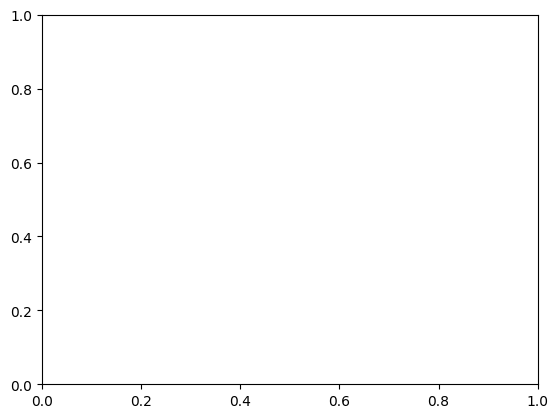

In [40]:
# === PRECISION-RECALL & F1 CURVES ===
# Extract precision-recall data from coco_eval
precision = coco_eval.eval["precision"]
recall = coco_eval.eval["recall"]
pr = np.mean(precision, axis=(0, 1, 2))
r_vals = coco_eval.params.recThrs
p_vals = pr[:len(r_vals)]

plt.figure()
plt.plot(r_vals, p_vals, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "PR_curve.png"))
plt.close()

f1 = 2 * (p_vals * r_vals) / (p_vals + r_vals + 1e-8)
plt.figure()
plt.plot(r_vals, f1, label="F1 Curve")
plt.xlabel("Recall")
plt.ylabel("F1 Score")
plt.title("F1 vs Recall")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "F1_curve.png"))
plt.close()

print("✅ Curves saved in", OUTPUT_DIR)


In [41]:
import json
with open("./dataset/brain_tumor/valid/_annotations.coco.json") as f:
    data = json.load(f)
print(data["categories"])


[{'id': 0, 'name': 'Glioma-Meningioma-NoTumor-Pituit', 'supercategory': 'none'}, {'id': 1, 'name': 'Glioma', 'supercategory': 'Glioma-Meningioma-NoTumor-Pituit'}, {'id': 2, 'name': 'Meningioma', 'supercategory': 'Glioma-Meningioma-NoTumor-Pituit'}, {'id': 3, 'name': 'No Tumor', 'supercategory': 'Glioma-Meningioma-NoTumor-Pituit'}, {'id': 4, 'name': 'Pituitary', 'supercategory': 'Glioma-Meningioma-NoTumor-Pituit'}]
